# Package

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Membaca file Excel 'Curah Hujan_2011-2020.xlsx' menggunakan engine 'openpyxl'
df = pd.read_excel(r"C:\Users\asus\OneDrive\Desktop\Lengkap Berkas Skripsi\Data Skripsi\Curah Hujan_2011-2020_FIX.xlsx", engine='openpyxl')

In [3]:
# Mengubah kolom 'Time' menjadi format datetime dengan format 'yyyy-mm-dd'
df['Time'] = pd.to_datetime(df['Time'], format='%Y-%m-%d')

In [4]:
# Membuat variabel 'train_dates' yang berisi nilai waktu dari kolom 'Time'
train_dates = pd.to_datetime(df['Time'])

In [5]:
df['Temp_7'] = df['Temperature/°C'].shift(7)

In [6]:
df['Hum_7'] = df['Humidity/%'].shift(7)


In [7]:
# Membuat variabel lag untuk curah hujan (Rainfall) dengan pergeseran beberapa hari yang telah ditentukan
lag_ch = [1, 3, 4, 6, 7, 9, 10, 11, 12, 15, 16, 18, 21, 22, 24, 25, 26]
for i in lag_ch:
    df[f'Ch_lag{i}'] = df['Curah Hujan/mm'].shift(i)

In [8]:
# Membuat variabel rata-rata curah hujan berdasarkan jendela waktu dari 2 hingga 30 hari
window_ch = list(range(2, 31))
for i in window_ch:
    df[f'Ch_win{i}'] = df['Curah Hujan/mm'].rolling(window=i, min_periods=1).mean()

In [9]:
# Mengisi nilai yang hilang (NaN) dengan metode backfill (mengisi dengan nilai dari bawah ke atas)
df.fillna(method='bfill', inplace=True)
# Mengisi nilai yang hilang (NaN) dengan metode forward fill (mengisi dengan nilai dari atas ke bawah)
df.fillna(method='ffill', inplace=True)

C:\Users\asus\AppData\Local\Temp\ipykernel_8348\2711203625.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)
C:\Users\asus\AppData\Local\Temp\ipykernel_8348\2711203625.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [10]:
# Menghapus kolom 'Time' dari DataFrame
df_final = df.drop('Time', axis=1)

In [11]:
# Mengimpor XGBRegressor dari pustaka xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

In [12]:
# Memisahkan data menjadi data latih (2011-2019) dan data uji (2020)
# Data latih: 3287 data, Data uji: 366 data
# Menghapus kolom 'Curah Hujan/mm' dari fitur (X)
X = df_final.drop('Curah Hujan/mm', axis=1)
y = df_final['Curah Hujan/mm']

In [13]:
# Memisahkan data latih dan data uji berdasarkan indeks
train_x, train_y = X[:3287], y[:3287]
test_x, test_y = X[3287:], y[3287:]

In [14]:
# Mencetak bentuk (shape) dari data latih dan data uji
print("Train X shape:", train_x.shape)
print("Train Y shape:", train_y.shape)
print("Test X shape:", test_x.shape)
print("Test Y shape:", test_y.shape)

Train X shape: (3287, 53)
Train Y shape: (3287,)
Test X shape: (366, 53)
Test Y shape: (366,)


In [15]:
# Mengimpor StandardScaler dari pustaka sklearn untuk scaling (normalisasi data)
from sklearn.preprocessing import StandardScaler

In [16]:
# Menerapkan scaling pada data latih dan data uji
scaler = StandardScaler()
train_x = scaler.fit_transform(train_x)
test_x = scaler.transform(test_x)

c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a fu

In [17]:
# Membuat model XGBRegressor dengan parameter n_estimators=1000 dan learning_rate=0.1
model = XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=3, random_state=42)

In [18]:
# Melatih model menggunakan data latih dan menilai dengan metrik RMSE dan MAE pada data latih dan data uji
model.fit(train_x, train_y, eval_metric=["rmse", "mae"], eval_set=[(train_x, train_y), (test_x, test_y)], verbose=True)

[0]	validation_0-rmse:5.81093	validation_0-mae:3.86127	validation_1-rmse:17.85184	validation_1-mae:10.34381
[1]	validation_0-rmse:5.39874	validation_0-mae:3.56933	validation_1-rmse:16.97974	validation_1-mae:9.69456
[2]	validation_0-rmse:5.01309	validation_0-mae:3.29876	validation_1-rmse:16.21657	validation_1-mae:9.12733
[3]	validation_0-rmse:4.67140	validation_0-mae:3.05482	validation_1-rmse:15.59403	validation_1-mae:8.60474
[4]	validation_0-rmse:4.35681	validation_0-mae:2.83834	validation_1-rmse:14.86982	validation_1-mae:8.08652
[5]	validation_0-rmse:4.08728	validation_0-mae:2.63380	validation_1-rmse:14.34778	validation_1-mae:7.70189
[6]	validation_0-rmse:3.81889	validation_0-mae:2.45591	validation_1-rmse:13.71710	validation_1-mae:7.23409
[7]	validation_0-rmse:3.59598	validation_0-mae:2.29413	validation_1-rmse:13.20690	validation_1-mae:6.88486
[8]	validation_0-rmse:3.37525	validation_0-mae:2.15202	validation_1-rmse:12.60113	validation_1-mae:6.50057
[9]	validation_0-rmse:3.18506	valida

c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\xgboost\sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(


[29]	validation_0-rmse:1.42398	validation_0-mae:0.89651	validation_1-rmse:7.86514	validation_1-mae:3.44770
[30]	validation_0-rmse:1.38626	validation_0-mae:0.86744	validation_1-rmse:7.73156	validation_1-mae:3.38955
[31]	validation_0-rmse:1.34983	validation_0-mae:0.85290	validation_1-rmse:7.57574	validation_1-mae:3.30089
[32]	validation_0-rmse:1.32839	validation_0-mae:0.84334	validation_1-rmse:7.45521	validation_1-mae:3.26180
[33]	validation_0-rmse:1.30469	validation_0-mae:0.82385	validation_1-rmse:7.35934	validation_1-mae:3.22108
[34]	validation_0-rmse:1.28052	validation_0-mae:0.80097	validation_1-rmse:7.27427	validation_1-mae:3.19096
[35]	validation_0-rmse:1.24585	validation_0-mae:0.78077	validation_1-rmse:7.21200	validation_1-mae:3.12958
[36]	validation_0-rmse:1.23022	validation_0-mae:0.77279	validation_1-rmse:7.12015	validation_1-mae:3.09239
[37]	validation_0-rmse:1.21050	validation_0-mae:0.76140	validation_1-rmse:7.04654	validation_1-mae:3.06332
[38]	validation_0-rmse:1.18355	valida

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [19]:
# Mencetak semua parameter model
print(model.get_params())

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 500, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [20]:
# Mengimpor metrik evaluasi dari sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [21]:
# Membuat prediksi pada data latih
train_pred = model.predict(train_x)

In [22]:
# Menghitung metrik evaluasi pada data latih
mse_train = mean_squared_error(train_y, train_pred)
mae_train = mean_absolute_error(train_y, train_pred)
rmse_train = np.sqrt(mse_train)


c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseD

In [23]:
# Mencetak nilai MAE, RMSE, SMAPE, dan R2 untuk data latih
print(f'MAE Train: {mae_train}')
print(f'RMSE Train: {rmse_train}')
print('------------------------------')

MAE Train: 0.10609697614791536
RMSE Train: 0.1572800451383547
------------------------------


In [24]:
# Membuat prediksi untuk data uji
pred = model.predict(test_x)

In [25]:
# Menghitung MSE, MAE, RMSE, R2, dan SMAPE untuk data uji
mse_test = mean_squared_error(test_y, pred)
mae_test = mean_absolute_error(test_y, pred)
rmse_test = np.sqrt(mse_test)

c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseD

In [26]:
# Mencetak hasil evaluasi model untuk data uji
print(f'MAE Test: {mae_test}')
print(f'RMSE Test: {rmse_test}')

MAE Test: 1.931505440081383
RMSE Test: 5.213465310457395


In [27]:
# Membuat plot untuk membandingkan data aktual vs prediksi pada data latih
train_pred = model.predict(train_x)

In [28]:
# Mengambil data tahun untuk data latih
year_train = df['Time'][:3287]

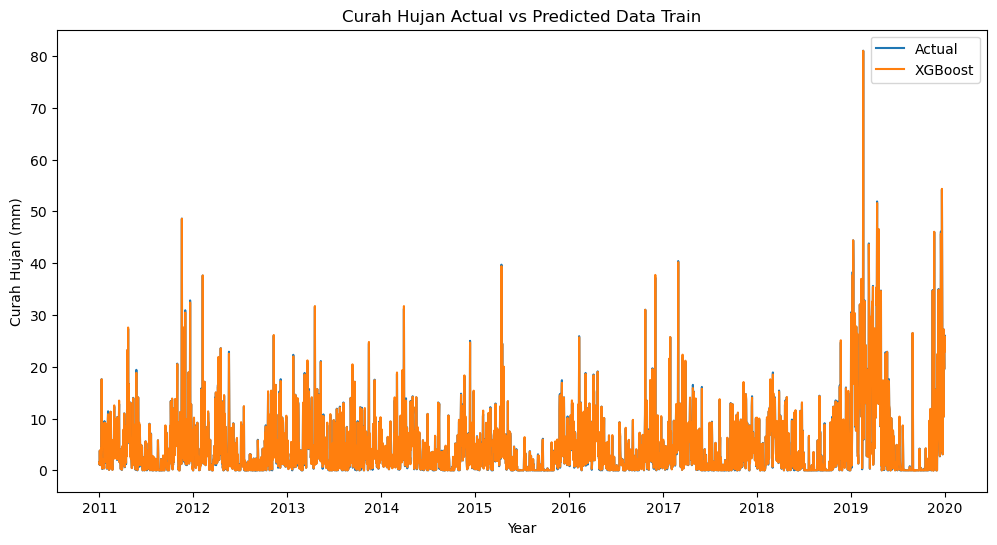

In [29]:
# Membuat plot data aktual dan prediksi untuk data latih
plt.figure(figsize=(12, 6))
plt.plot(year_train, train_y, label='Actual')
plt.plot(year_train, train_pred, label='XGBoost')
plt.title('Curah Hujan Actual vs Predicted Data Train')
plt.xlabel('Year')
plt.ylabel('Curah Hujan (mm)')
plt.legend()
plt.show()

In [30]:
# Membuat plot untuk membandingkan data aktual vs prediksi pada data uji
# Mengambil data tahun untuk data uji
year_test = df['Time'][3287:]

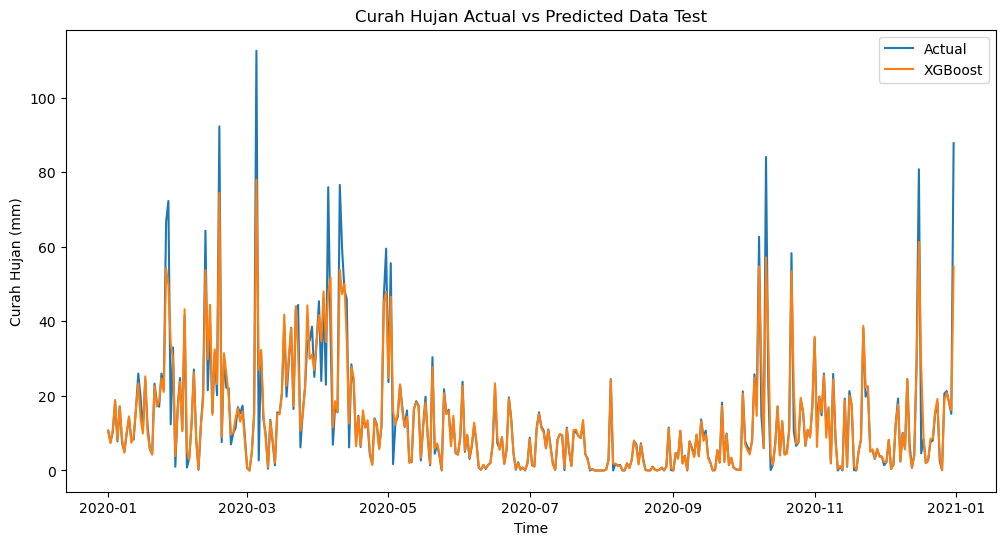

In [31]:
# Membuat plot data aktual dan prediksi untuk data uji
plt.figure(figsize=(12, 6))
plt.plot(year_test, test_y, label='Actual')
plt.plot(year_test, pred, label='XGBoost')
plt.title('Curah Hujan Actual vs Predicted Data Test')
plt.xlabel('Time')
plt.ylabel('Curah Hujan (mm)')
plt.legend()
plt.show()

In [32]:
# Mengambil hasil evaluasi dari model
results = model.evals_result()
# Mengubah RMSE menjadi MSE untuk kedua set data
results['validation_0']['rmse'] = np.sqrt(results['validation_0']['rmse'])
results['validation_1']['rmse'] = np.sqrt(results['validation_1']['rmse'])

In [33]:
# Menyimpan model yang telah dilatih menggunakan joblib
# import joblib

# Menyimpan model dalam file 'xgboost_model.pkl'
# joblib.dump(model, 'xgboost_model.pkl')

# SHAP

In [34]:
import shap

# Membuat objek explainer menggunakan model yang sudah dilatih
explainer = shap.Explainer(model)

c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
# Menghitung nilai SHAP untuk setiap fitur pada data latih
shap_values = explainer(train_x)

In [36]:
# Mendapatkan nama-nama fitur dari DataFrame X
feature_name = X.columns

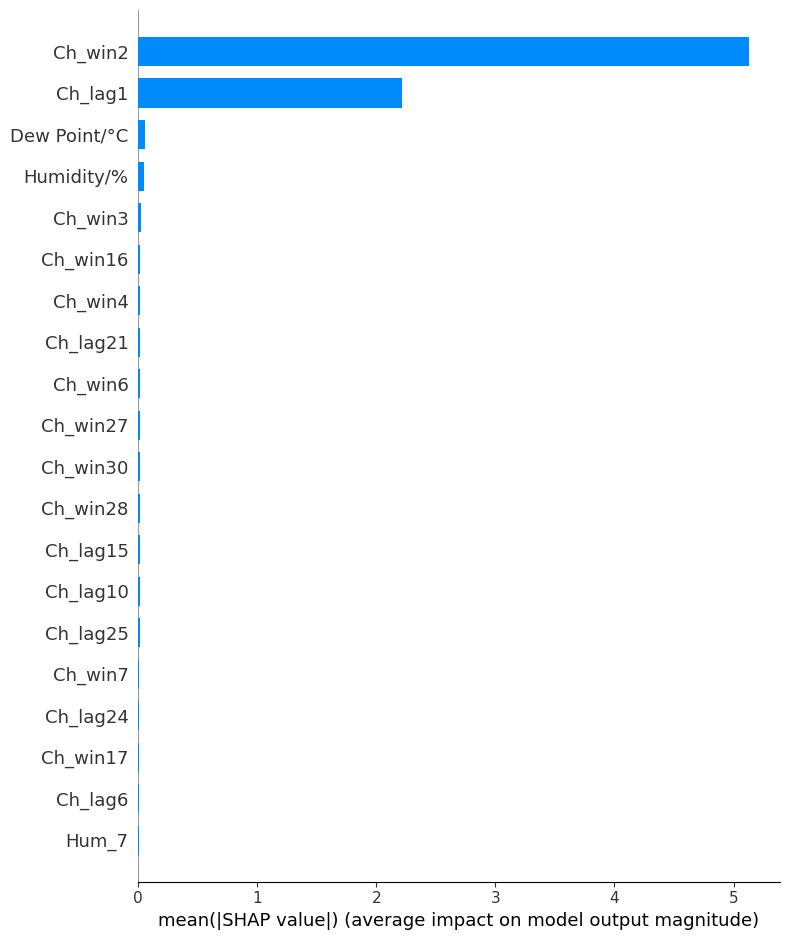

In [37]:
# Membuat plot pentingnya fitur menggunakan nilai SHAP dalam bentuk bar
# Plot ini menunjukkan pengaruh setiap fitur terhadap prediksi model
shap.summary_plot(shap_values, train_x, feature_names=feature_name, plot_type='bar')

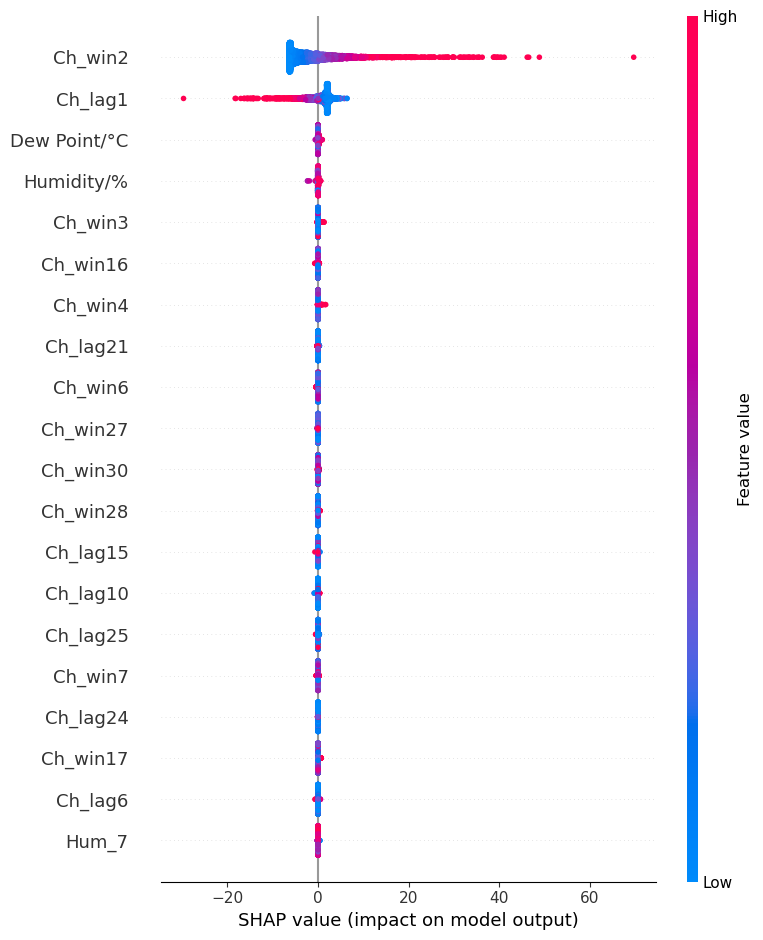

In [38]:
# Membuat plot pentingnya fitur menggunakan nilai SHAP dalam bentuk swarm plot
# Plot ini menunjukkan distribusi nilai SHAP untuk setiap fitur
shap.summary_plot(shap_values, train_x, feature_names=feature_name)

In [39]:
x_train = X[:3287]
x_train = x_train[['Ch_lag1','Ch_win2']]

train_pred = pd.DataFrame(train_pred)

In [40]:
# Cek indeks kolom
print(X.columns.get_loc('Ch_win2'))
print(X.columns.get_loc('Ch_lag1'))

24
7


In [41]:
shap_win2 = [lst[24] for lst in shap_values.values]
shap_lag1 = [lst[7] for lst in shap_values.values]

Text(0.5, 0.9, 'Korelasi: 0.91')

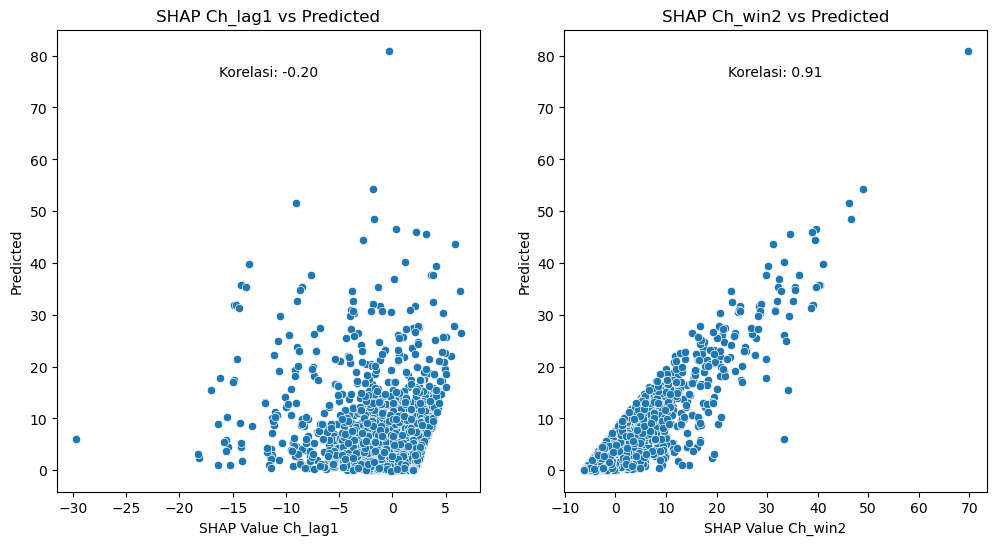

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.scatterplot(x = shap_lag1, y = train_pred[0], ax = ax[0])
ax[0].set_title('SHAP Ch_lag1 vs Predicted')
ax[0].set_xlabel('SHAP Value Ch_lag1')
ax[0].set_ylabel('Predicted')
corr_coef = pd.Series(shap_lag1).corr(train_pred[0])
ax[0].text(0.5, 0.9, f'Korelasi: {corr_coef:.2f}', ha = 'center', transform=ax[0].transAxes)

sns.scatterplot(x = shap_win2, y = train_pred[0], ax = ax[1])
ax[1].set_title('SHAP Ch_win2 vs Predicted')
ax[1].set_xlabel('SHAP Value Ch_win2')
ax[1].set_ylabel('Predicted')
corr_coef = pd.Series(shap_win2).corr(train_pred[0])
ax[1].text(0.5, 0.9, f'Korelasi: {corr_coef:.2f}', ha='center', transform=ax[1].transAxes)

# Tuning

In [43]:
# Mengimpor pustaka yang diperlukan
from tqdm import tqdm
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [44]:
# Mengatur kolom 'Time' sebagai indeks DataFrame
df.set_index('Time', inplace=True)

In [45]:
# Mendefinisikan fungsi walk-forward validation dengan tuning hyperparameter
def walk_forward_validation_with_tuning(df, window_size=5):
    # Mengambil daftar tahun yang unik dari indeks DataFrame
    years = df.index.year.unique()
    results = []

    # Mendefinisikan grid hyperparameter untuk tuning
    param_grid = {
        'learning_rate': [0.3, 0.01, 0.1],  # Variasi learning rate
        'n_estimators': [100, 500, 1000],   # Variasi jumlah estimator
        'max_depth': [3, 5, 7, 9],          # Variasi kedalaman maksimum
        'random_state':[42]                 # Konsisten hasil
    }

    # Loop untuk walk-forward validation
    for i in range(len(years) - window_size):
        start_year = years[i]
        # Membuat mask untuk data latih (4 tahun) dan data uji (tahun ke-5)
        train_mask = (df.index.year >= start_year) & (df.index.year < start_year + 4)
        test_mask = (df.index.year == start_year + 4)
        train_x, train_y = df.loc[train_mask].drop('Curah Hujan/mm', axis=1), df.loc[train_mask]['Curah Hujan/mm']
        test_x, test_y = df.loc[test_mask].drop('Curah Hujan/mm', axis=1), df.loc[test_mask]['Curah Hujan/mm']

        # Melakukan scaling data latih dan data uji
        scaler = StandardScaler()
        train_x = scaler.fit_transform(train_x)
        test_x = scaler.transform(test_x)

        # Tuning hyperparameter untuk setiap kombinasi parameter pada grid
        for params in tqdm(list(ParameterGrid(param_grid)), desc=f"Tuning for {start_year}-{start_year+3}"):
            # Membuat model dengan hyperparameter yang sedang diuji
            model = XGBRegressor(**params)
            model.fit(train_x, train_y)  # Melatih model dengan data latih

            # Melakukan prediksi pada data uji
            pred = model.predict(test_x)
            # Menghitung metrik evaluasi
            rmse = mean_squared_error(test_y, pred, squared=False)  # Menghitung RMSE
            mae = mean_absolute_error(test_y, pred)  # Menghitung MAE

            # Menyimpan hasil untuk setiap kombinasi hyperparameter
            results.append({
                'sample': f"{start_year}-{start_year+3} to {start_year+4}",
                'training_year': f"{start_year}-{start_year+3}",
                'testing_year': start_year + 4,
                **params,  # Menyimpan hyperparameter yang digunakan
                'rmse': rmse, 
                'mae': mae,
            })
    # Mengembalikan hasil sebagai DataFrame
    return pd.DataFrame(results)

In [46]:
# Menjalankan walk-forward validation dengan tuning hyperparameter
df_results = walk_forward_validation_with_tuning(df)

c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\asus\miniconda3\envs\kelas-pyhon\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a fu

In [47]:
print(df_results)

                sample training_year  testing_year  learning_rate  max_depth  \
0    2011-2014 to 2015     2011-2014          2015            0.3          3   
1    2011-2014 to 2015     2011-2014          2015            0.3          3   
2    2011-2014 to 2015     2011-2014          2015            0.3          3   
3    2011-2014 to 2015     2011-2014          2015            0.3          5   
4    2011-2014 to 2015     2011-2014          2015            0.3          5   
..                 ...           ...           ...            ...        ...   
175  2015-2018 to 2019     2015-2018          2019            0.1          7   
176  2015-2018 to 2019     2015-2018          2019            0.1          7   
177  2015-2018 to 2019     2015-2018          2019            0.1          9   
178  2015-2018 to 2019     2015-2018          2019            0.1          9   
179  2015-2018 to 2019     2015-2018          2019            0.1          9   

     n_estimators  random_state      rm

In [48]:
# Menghitung rata-rata RMSE untuk setiap kombinasi hyperparameter
df_avg_rmse = df_results.groupby(['learning_rate', 'max_depth', 'n_estimators'])['rmse'].mean().sort_values()
df_avg_rmse_1 = pd.DataFrame(df_avg_rmse)
print(df_avg_rmse_1)

                                          rmse
learning_rate max_depth n_estimators          
0.10          3         1000          2.063432
                        500           2.067394
                        100           2.106328
0.01          3         1000          2.127055
0.30          3         1000          2.176583
                        500           2.177068
                        100           2.217112
0.01          5         1000          2.292000
0.10          5         1000          2.302524
                        500           2.302558
                        100           2.306129
0.01          7         1000          2.333449
0.10          7         500           2.346954
                        1000          2.346954
0.01          3         500           2.348144
0.10          9         500           2.348351
                        1000          2.348351
              7         100           2.349674
0.01          5         500           2.349720
             

In [49]:
# Menghitung rata-rata MAE untuk setiap kombinasi hyperparameter
df_avg_mae = df_results.groupby(['learning_rate', 'max_depth', 'n_estimators'])['mae'].mean().sort_values()
df_avg_mae_1 = pd.DataFrame(df_avg_mae)
print(df_avg_mae_1)

                                           mae
learning_rate max_depth n_estimators          
0.10          3         1000          0.906539
                        500           0.910770
0.01          3         1000          0.957352
0.10          3         100           0.970079
0.30          3         500           0.984025
                        1000          0.984534
0.01          7         1000          0.984943
              5         1000          0.986169
0.10          7         500           1.000941
                        1000          1.000941
              5         1000          1.001815
                        500           1.001827
              7         100           1.002353
              5         100           1.008090
0.30          3         100           1.008471
0.01          9         1000          1.013083
0.10          9         500           1.020267
                        1000          1.020267
0.01          7         500           1.021757
0.10         

In [50]:
# Mengekspor hasil ke file CSV
df_results.to_csv('xgboost_walk_forward_tuning.csv', index=False)

In [51]:
# Mengekspor hasil ke file CSV
df_avg_rmse_1.to_csv('xgboost_walk_forward_tuning_Rata2_RMSE.csv', index=True)
df_avg_mae_1.to_csv('xgboost_walk_forward_tuning_Rata2_MAE.csv', index=True)